In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/CitDat_Stratified"

print("Dataset Root:", DATASET_PATH)
print("Files inside root:", os.listdir(DATASET_PATH))

print("\nTrain images:", len(os.listdir(f"{DATASET_PATH}/images/train")))
print("Val images:", len(os.listdir(f"{DATASET_PATH}/images/val")))
print("Test images:", len(os.listdir(f"{DATASET_PATH}/images/test")))

Dataset Root: /content/drive/MyDrive/CitDat_Stratified
Files inside root: ['data.yaml', 'images', 'labels']

Train images: 2067
Val images: 591
Test images: 296


In [ ]:
!pip install ultralytics



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
print("Ultralytics installed successfully!")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics installed successfully!


In [ ]:
DATA_YAML = "/content/drive/MyDrive/CitDat_Stratified/data.yaml"

import yaml
with open(DATA_YAML, "r") as f:
    print(yaml.safe_load(f))


{'path': '/content/drive/MyDrive/CitDat_Stratified', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'nc': 3, 'names': {0: 'Zinc_Deficient', 1: 'HLB', 2: 'Healthy'}}


In [ ]:
model = YOLO("yolov8n.pt")  # nano = lightweight baseline


In [ ]:
from ultralytics import YOLO

# Load lightweight YOLOv8 nano model
model = YOLO("yolov8n.pt")

model.train(
    data="/content/drive/MyDrive/CitDat_Stratified/data.yaml",
    epochs=60,
    imgsz=640,

    # Early stopping
    patience=20,

    # Geometry
    degrees=10.0,
    translate=0.1,
    scale=0.5,

    # Flip
    fliplr=0.5,
    flipud=0.3,

    # Augmentation
    mosaic=1.0,
    mixup=0.05,

    # Always save directly to Drive
    project="/content/drive/MyDrive/CitDat_yolov8_result",
    name="CitDat_Baseline"
)



Ultralytics 8.4.27 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/CitDat_Stratified/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=CitDat_Baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dff343f6ae0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
model = YOLO('/content/drive/MyDrive/CitDat_yolov8_result/CitDat_Baseline/weights/best.pt')

In [ ]:
test_path = '/content/drive/MyDrive/CitDat_Stratified/images/test'

In [ ]:
results = model.predict(
    source=test_path,
    save=True,        # saves predicted images
    conf=0.25         # confidence threshold (adjust if needed)
)


image 1/296 /content/drive/MyDrive/CitDat_Stratified/images/test/healthy_0276.jpg: 640x640 1 Healthy, 576.5ms
image 2/296 /content/drive/MyDrive/CitDat_Stratified/images/test/healthy_0304.jpg: 640x640 1 Healthy, 222.5ms
image 3/296 /content/drive/MyDrive/CitDat_Stratified/images/test/healthy_0320_rot.jpg: 640x640 1 Healthy, 623.7ms
image 4/296 /content/drive/MyDrive/CitDat_Stratified/images/test/healthy_0334.jpg: 640x640 1 Healthy, 345.9ms
image 5/296 /content/drive/MyDrive/CitDat_Stratified/images/test/healthy_0336.jpg: 640x640 1 Healthy, 380.9ms
image 6/296 /content/drive/MyDrive/CitDat_Stratified/images/test/healthy_0341_rot.jpg: 640x640 1 Healthy, 361.4ms
image 7/296 /content/drive/MyDrive/CitDat_Stratified/images/test/healthy_0345.jpg: 640x640 1 Healthy, 224.7ms
image 8/296 /content/drive/MyDrive/CitDat_Stratified/images/test/healthy_0348.jpg: 640x640 1 Healthy, 298.2ms
image 9/296 /content/drive/MyDrive/CitDat_Stratified/images/test/healthy_0368.jpg: 640x640 1 Healthy, 222.6ms
i

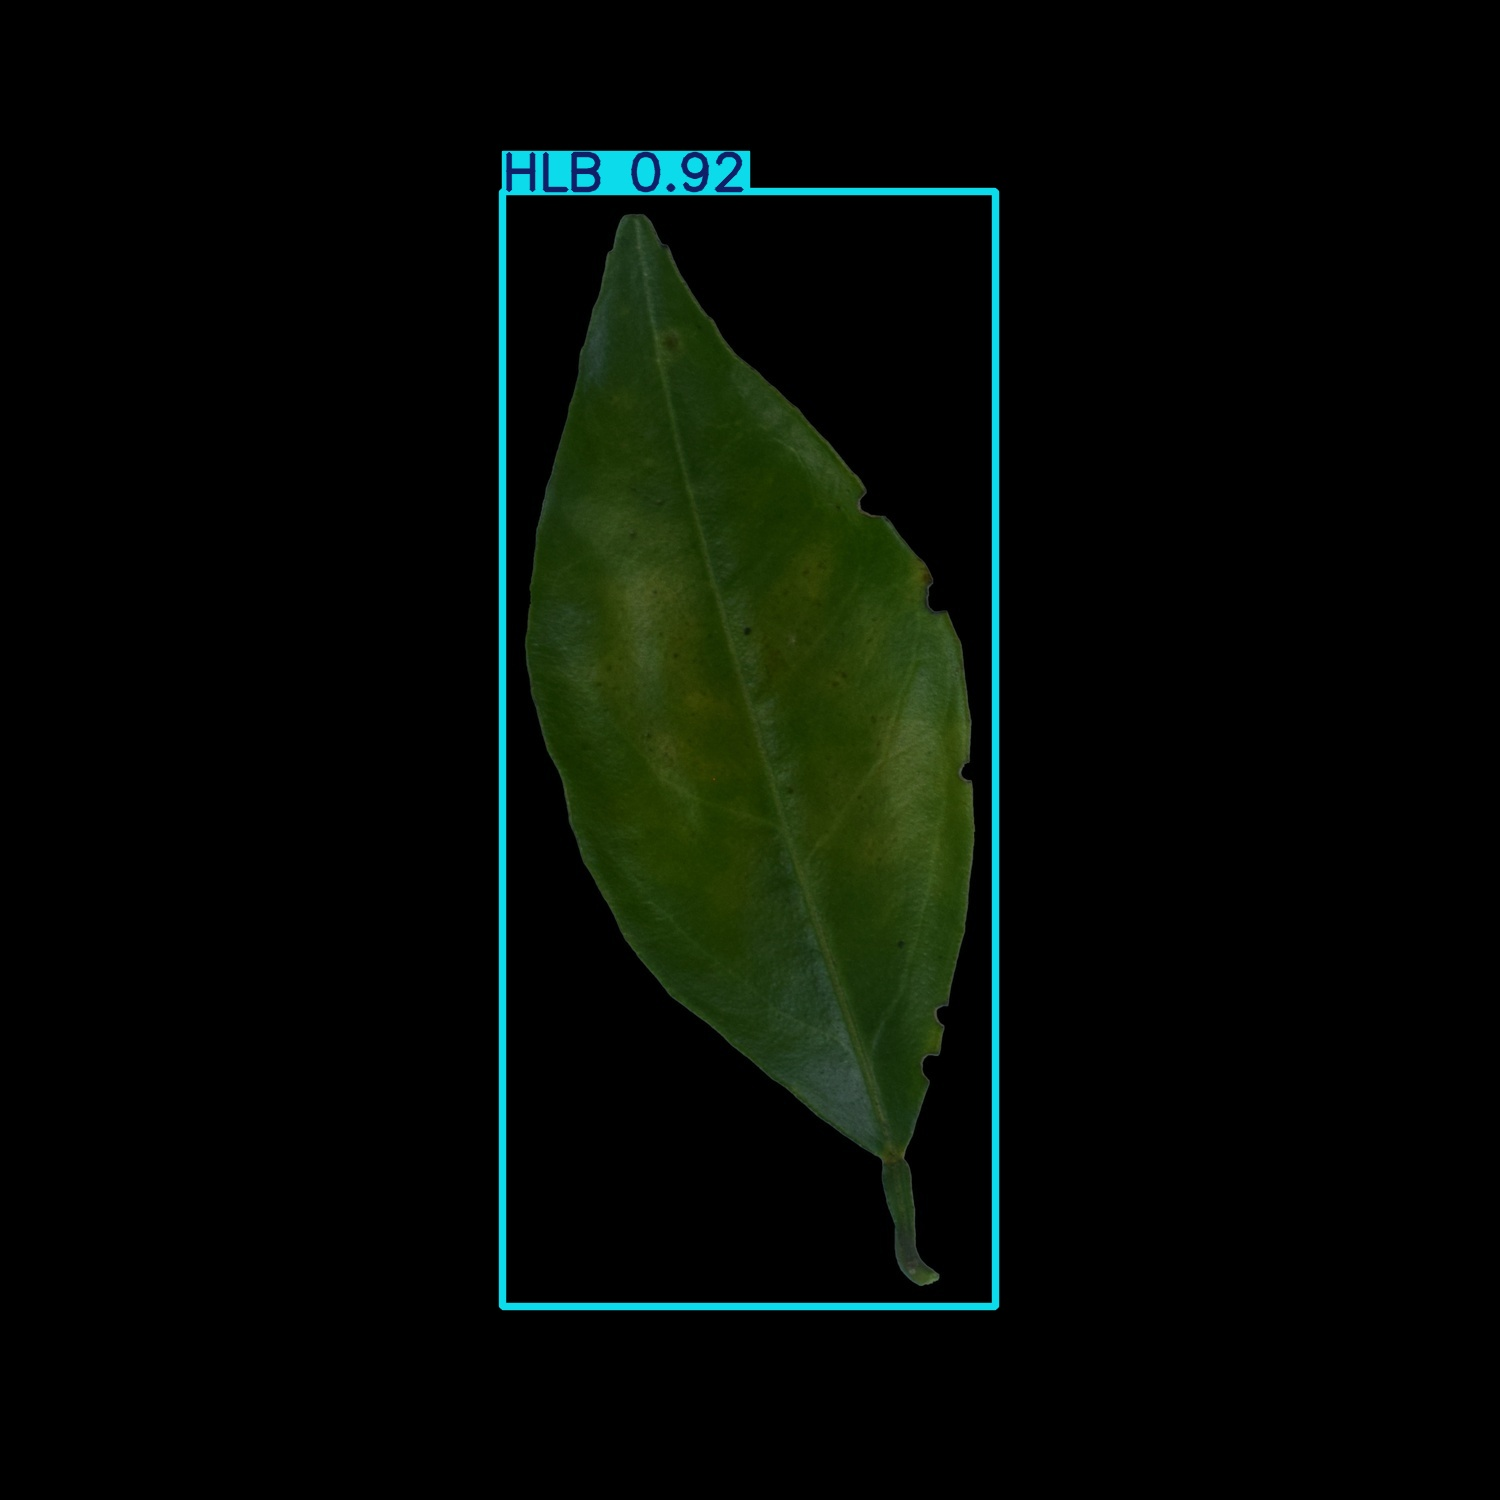

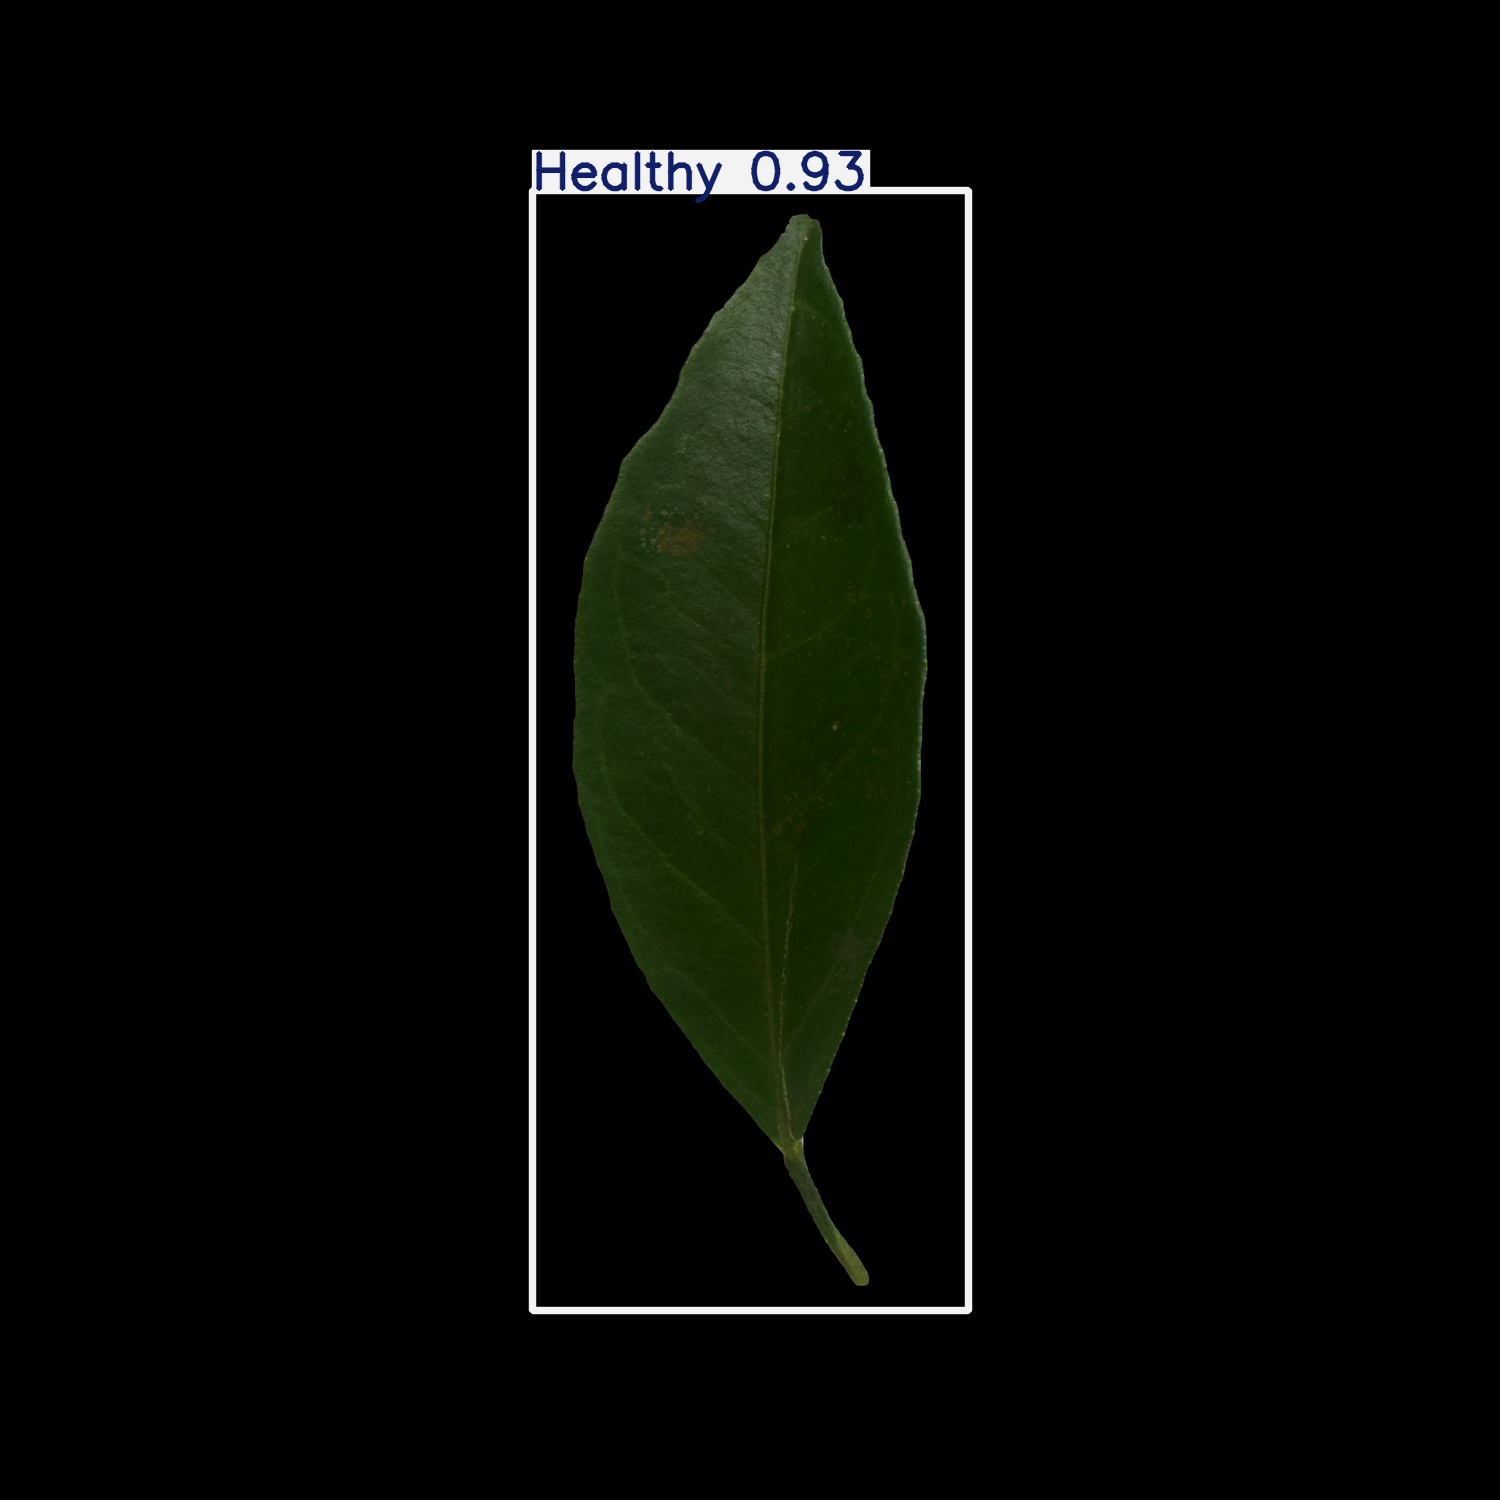

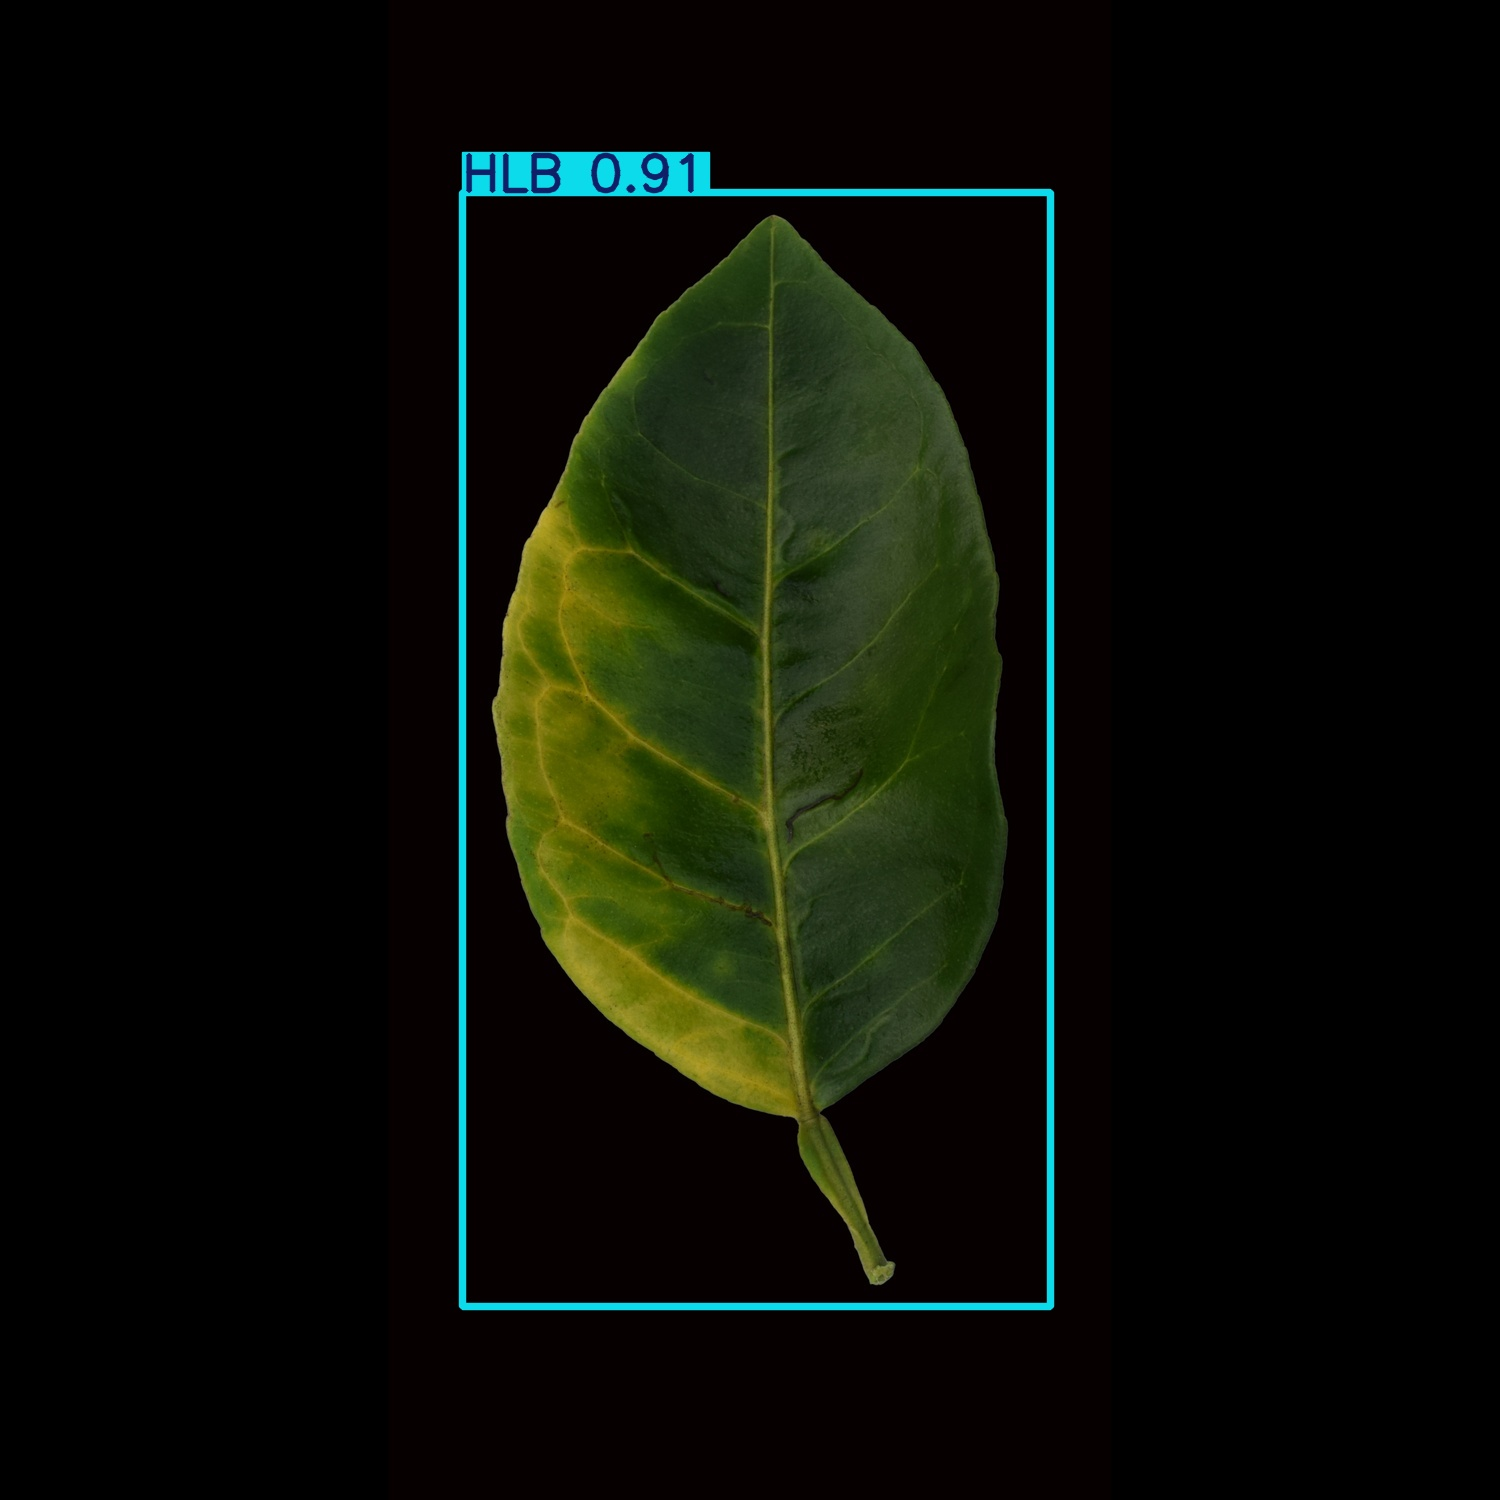

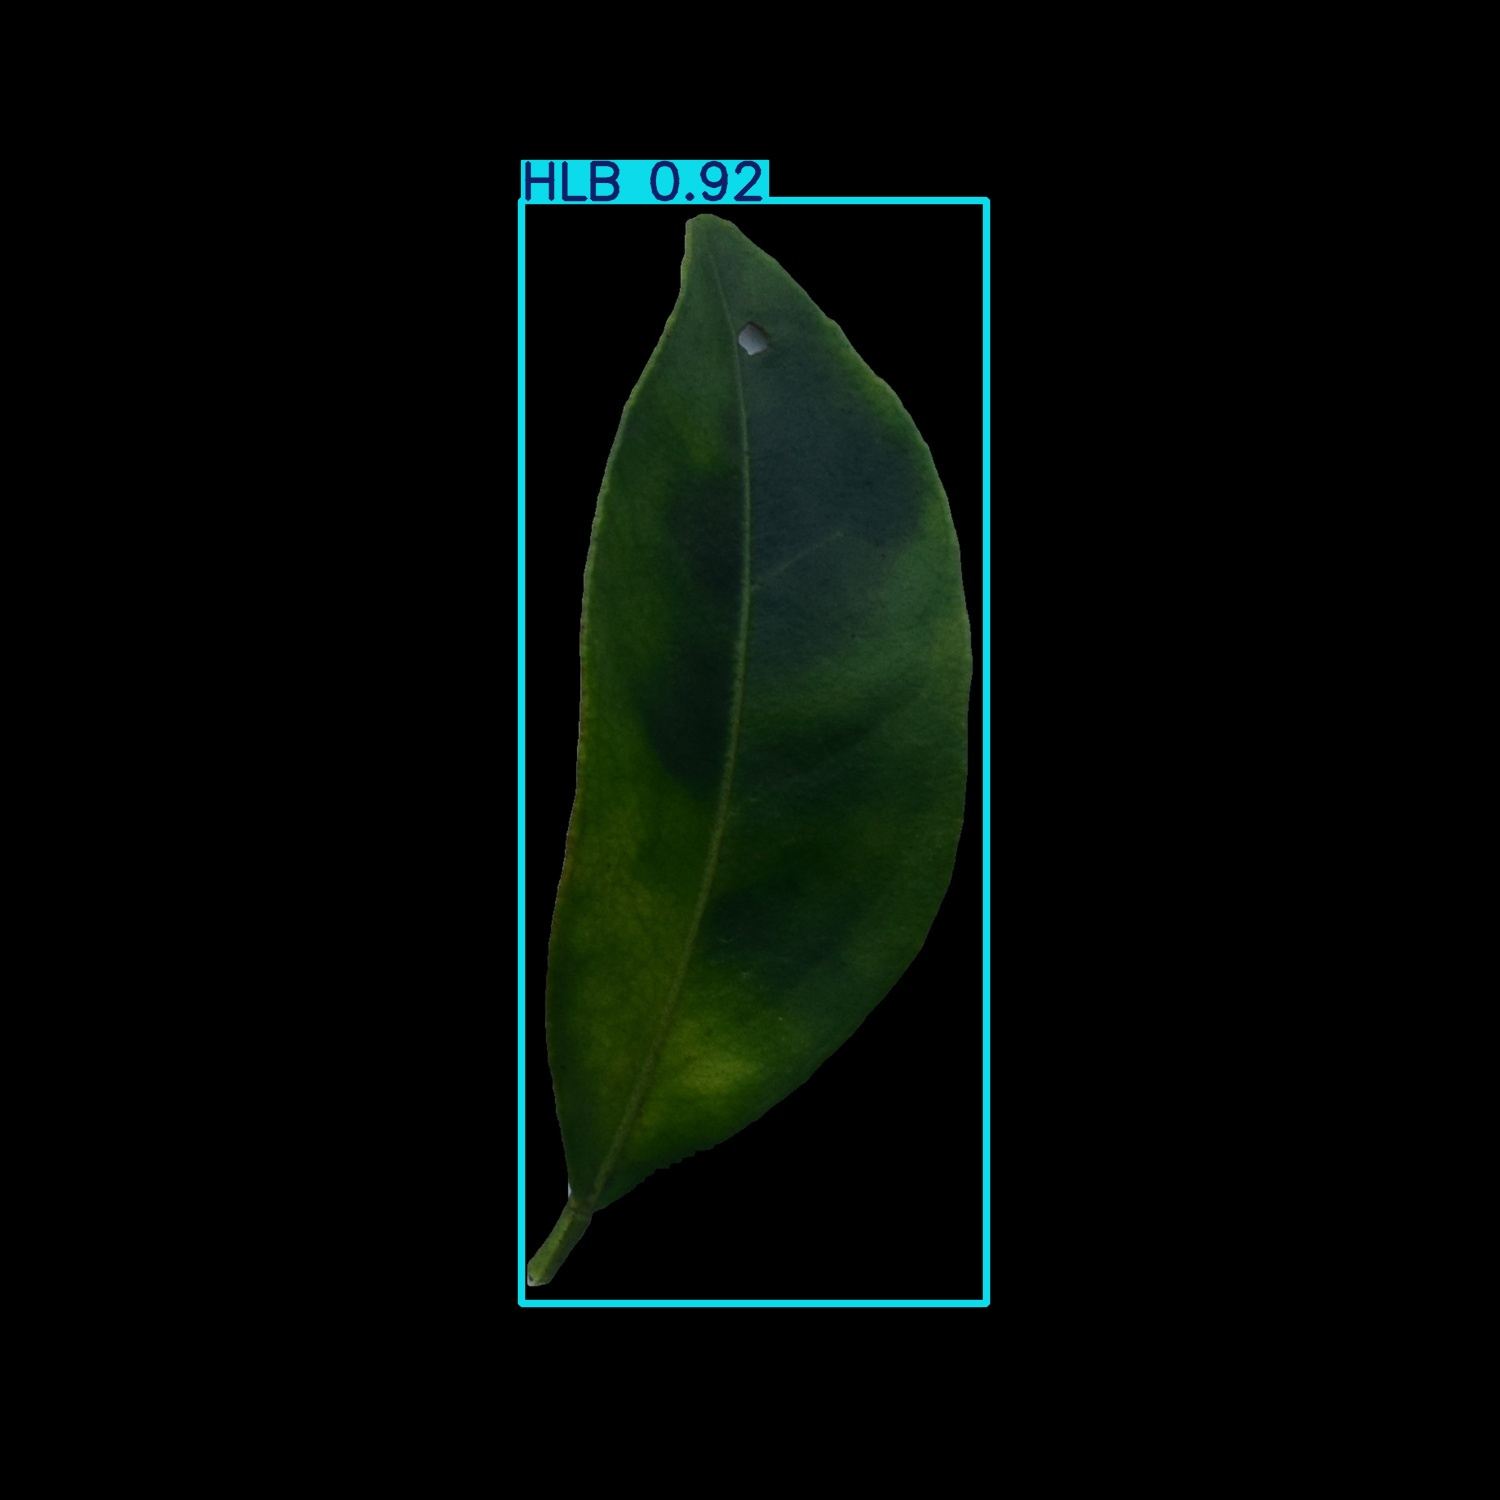

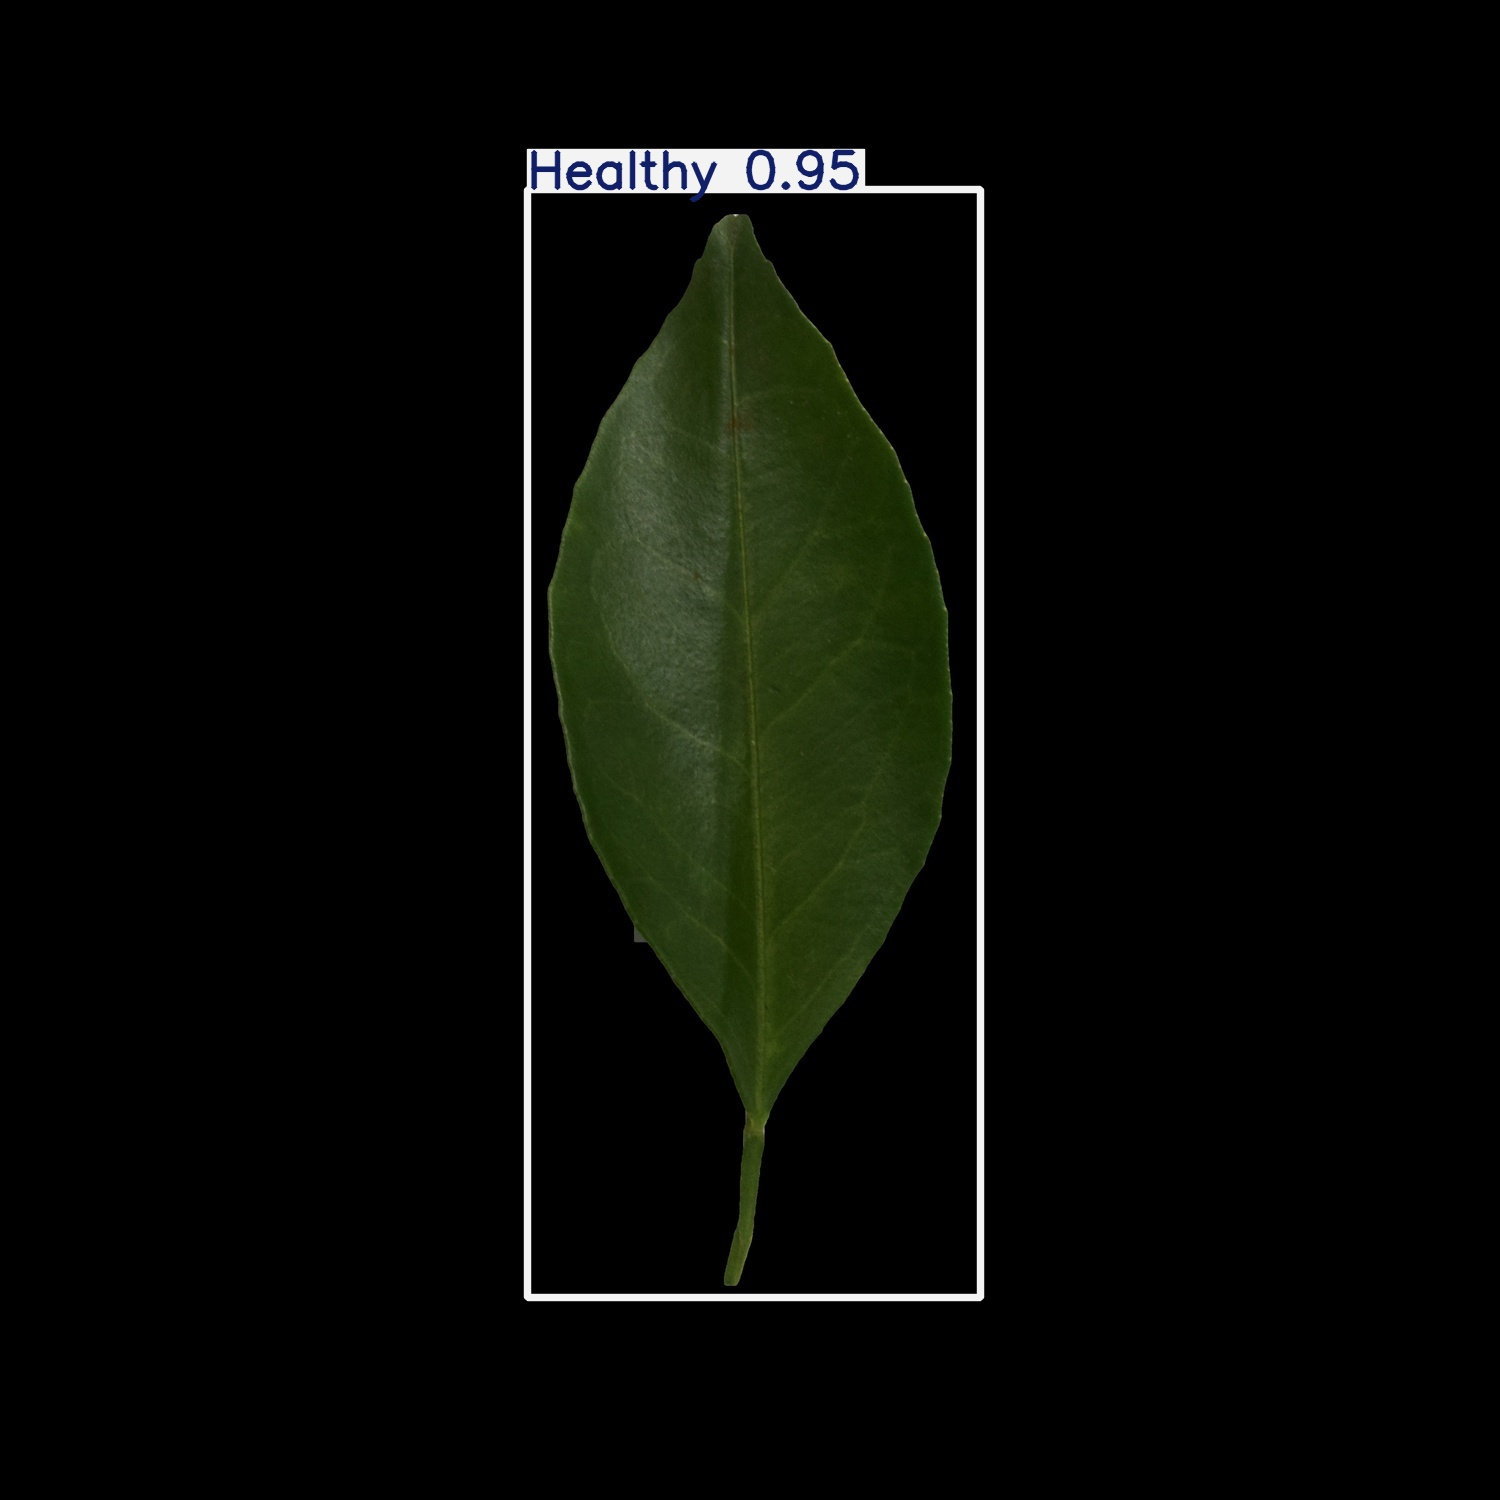

In [ ]:
import glob
from IPython.display import Image, display

image_paths = glob.glob('/content/runs/detect/predict/*.jpg')

for img in image_paths[:5]:
    display(Image(filename=img, width=600))  # 👈 resize here

In [ ]:
model.predict(
    source='/content/drive/MyDrive/CitDat_Stratified/images/test/healthy_0276.jpg',
    show=True,
    save=True
)

In [ ]:
import glob
import cv2
import os

input_folder = '/content/runs/detect/predict'
output_folder = '/content/MyDrive/resized_predictions'

os.makedirs(output_folder, exist_ok=True)

image_paths = glob.glob(input_folder + '/*.jpg')

for img_path in image_paths[:10]:  # choose how many you want
    img = cv2.imread(img_path)

    # Resize (keep aspect ratio)
    height, width = img.shape[:2]
    new_width = 800
    new_height = int((new_width / width) * height)

    resized = cv2.resize(img, (new_width, new_height))

    filename = os.path.basename(img_path)
    cv2.imwrite(os.path.join(output_folder, filename), resized)

print("Resized images saved!")

Resized images saved!
